ucimlrepo installed successfully!
Successfully imported ucimlrepo
Loading UCI Automobiles dataset...
   ✓ Loaded 205 rows via ucimlrepo

Preprocessing...
   Missing values per column (top 5):
normalized_losses    41
stroke                4
price                 4
bore                  4
horsepower            2

Engineering features and target label...
   Performance threshold : 4/8 conditions
   Track-oriented cars   : 31/205 (15.1%)

   Rows used for modelling: 203
   Train: 162 | Test: 41

   Class distribution before SMOTE: {0: np.int64(137), 1: np.int64(25)}
   Class distribution after SMOTE : {np.int64(0): np.int64(137), np.int64(1): np.int64(137)}

Training models...

  Logistic Regression
    Accuracy  : 0.902
    ROC-AUC   : 0.986
    Precision : 0.600
    Recall    : 1.000
    F1-Score  : 0.750

  Random Forest
    Accuracy  : 0.951
    ROC-AUC   : 0.990
    Precision : 0.750
    Recall    : 1.000
    F1-Score  : 0.857

Best model: Random Forest (ROC-AUC = 0.990)

Generating p

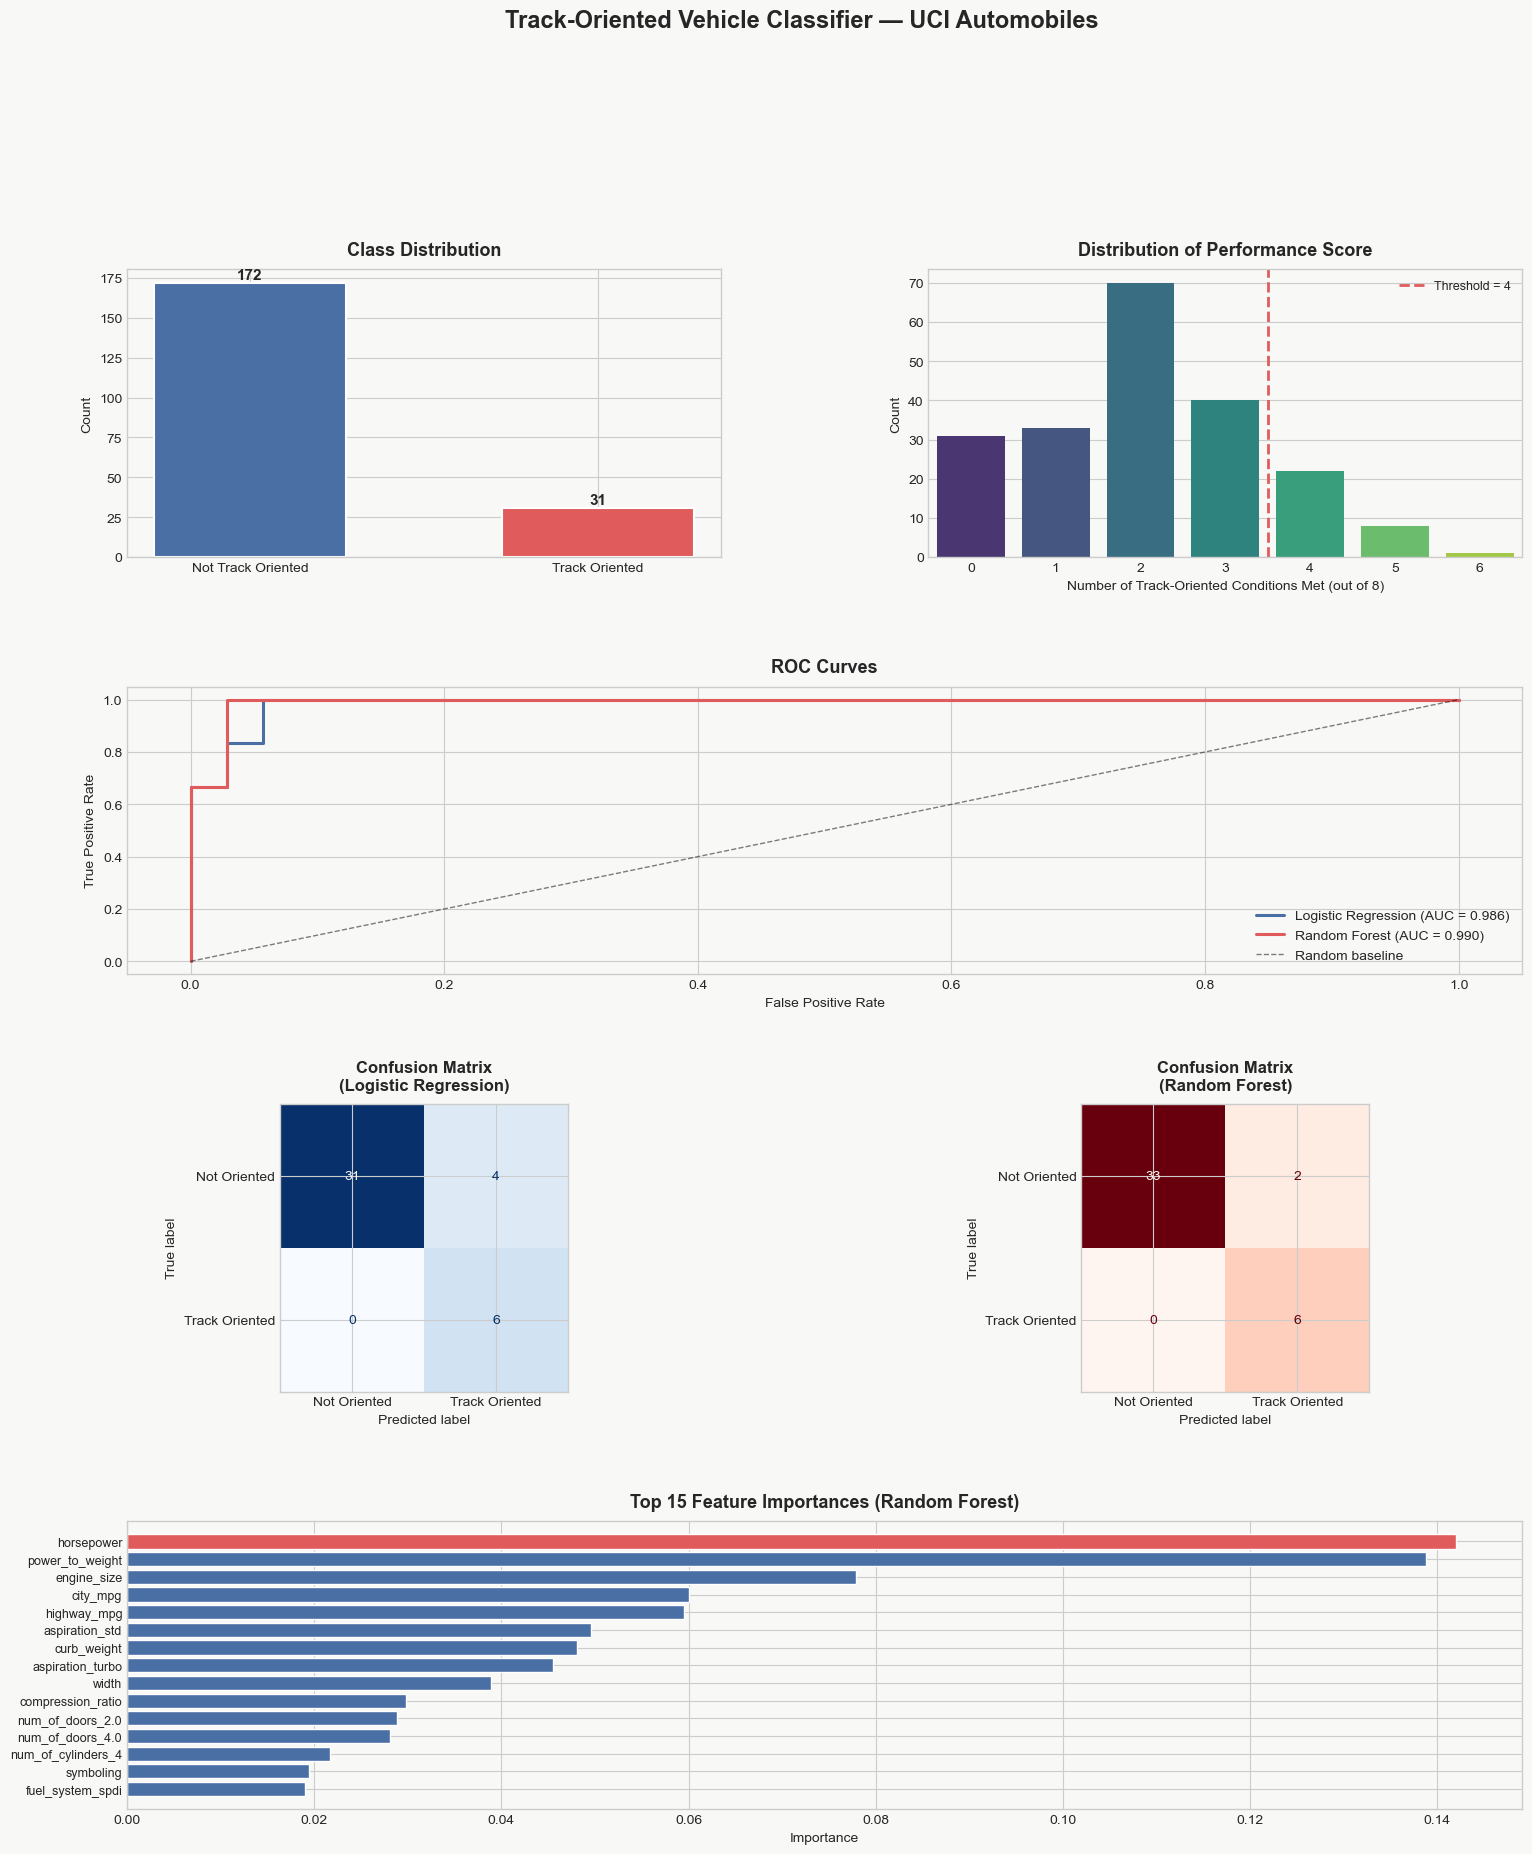


Demo predictions:

  Porsche 944 Turbo (hardtop)
    → TRACK ORIENTED (probability: 60.0%)

  Volvo 240 Wagon
    → Not Track Oriented (probability: 2.0%)

  Mazda RX-7 Convertible
    → Not Track Oriented (probability: 26.5%)


--- Enter Your Vehicle Specifications ---


Make (e.g., porsche, volvo):  honda
Body Style (e.g., hardtop, wagon, convertible):  convertible
Horsepower:  237
Curb Weight (lbs):  2860
Engine Size (cc):  2157
Fuel Type (gas/diesel):  gas
Aspiration (turbo/std):  na
Drive Wheels (rwd/fwd/4wd):  rwd
Engine Type (e.g., ohc, rotor):  dohc
Number of Cylinders (e.g., four, six):  four
Compression Ratio:  11.1
Peak RPM:  7800
City MPG:  18
Highway MPG:  25
Wheel Base (inches):  94.5
Length (inches):  162.2
Width (inches):  68.9
Height (inches):  50



--- Prediction Result ---
  Verdict     : TRACK ORIENTED
  Probability : 54.0%
-------------------------

✅ Done!
──────────────────────────────────────────────────
  Best model  : Random Forest
  ROC-AUC     : 0.990
  Accuracy    : 0.951
  F1-Score    : 0.857
──────────────────────────────────────────────────


In [4]:
# ─────────────────────────────────────────────
# INSTALL UCIMLREPO PACKAGE
# ─────────────────────────────────────────────
import sys
import subprocess

# Package name to install
package_name = "ucimlrepo"

try:
    # Run pip install command using subprocess
    # sys.executable ensures the pip associated with the current Python interpreter is used
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ucimlrepo"])
    
    print(f"{package_name} installed successfully!")

except subprocess.CalledProcessError as e:
    print(f"Error installing {package_name}: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

# After installation, you can import and use the package
try:
    import requests
    print(f"Successfully imported {package_name}")
except ImportError:
    print(f"Failed to import {package_name} after installation attempt")

# ─────────────────────────────────────────────
# SUMMARY OF SCRIPT
# ─────────────────────────────────────────────

"""
Track-Oriented Vehicle Classifier
===================================
Uses the UCI Automobiles dataset to predict whether a car is "track oriented"
based on engineered performance features and SMOTE-rebalanced training.

Pipeline:
  1. Load data (ucimlrepo if available, otherwise embedded fallback)
  2. Preprocess & engineer features
  3. Build track_oriented label via performance_sum scoring
  4. Train Logistic Regression + Random Forest with SMOTE rebalancing
  5. Evaluate & visualize results
  6. Interactive prediction for user-supplied car specs

Dataset: https://archive.ics.uci.edu/ml/datasets/Automobile
"""

# ─────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from io import StringIO

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from imblearn.over_sampling import SMOTE

# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────

COLUMNS = [
    "symboling", "normalized_losses", "make", "fuel_type", "aspiration",
    "num_of_doors", "body_style", "drive_wheels", "engine_location",
    "wheel_base", "length", "width", "height", "curb_weight",
    "engine_type", "num_of_cylinders", "engine_size", "fuel_system",
    "bore", "stroke", "compression_ratio", "horsepower", "peak_rpm",
    "city_mpg", "highway_mpg", "price",
]

print("Loading UCI Automobiles dataset...")

from ucimlrepo import fetch_ucirepo

automobile = fetch_ucirepo(id=10)

df = pd.concat([automobile.data.features, automobile.data.targets], axis=1)
df.columns = [c.replace("-", "_") for c in df.columns]
for col in COLUMNS:
    if col not in df.columns:
        df[col] = np.nan
df = df[COLUMNS]
print(f"   ✓ Loaded {len(df)} rows via ucimlrepo")

# ─────────────────────────────────────────────
# 2. PREPROCESS
# ─────────────────────────────────────────────

print("\nPreprocessing...")

numeric_cols = [
    "normalized_losses", "bore", "stroke", "horsepower", "peak_rpm",
    "price", "curb_weight", "engine_size", "compression_ratio",
    "wheel_base", "length", "width", "height", "city_mpg", "highway_mpg",
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

missing = df.isnull().sum().sort_values(ascending=False)
print("   Missing values per column (top 5):")
print(missing[missing > 0].head().to_string(header=False))

# ─────────────────────────────────────────────
# 3. ENGINEER FEATURES & TARGET LABEL
# ─────────────────────────────────────────────

print("\nEngineering features and target label...")

# Derived performance features
df["power_to_weight"] = df["horsepower"] / df["curb_weight"]
df["turbo_flag"] = (df["aspiration"] == "turbo").astype(int)

# Performance scoring: each condition contributes 1 point
hp_80       = df["horsepower"].quantile(0.80)
cw_40       = df["curb_weight"].quantile(0.40)
eng_80      = df["engine_size"].quantile(0.80)
width_80    = df["width"].quantile(0.80)
wb_60       = df["wheel_base"].quantile(0.60)
cr_80       = df["compression_ratio"].quantile(0.80)
ptw_80      = df["power_to_weight"].quantile(0.80)

conditions = [
    df["horsepower"]      > hp_80,
    df["curb_weight"]     < cw_40,
    df["engine_size"]     > eng_80,
    df["width"]           > width_80,
    df["wheel_base"]      < wb_60,
    df["compression_ratio"] > cr_80,
    df["power_to_weight"] > ptw_80,
    df["turbo_flag"]      == 1,
]
df["performance_sum"] = sum(conditions)

# A car scoring 4+ out of 8 conditions is considered track oriented
PERFORMANCE_THRESHOLD = 4
df["track_oriented"] = (df["performance_sum"] >= PERFORMANCE_THRESHOLD).astype(int)

track_count = df["track_oriented"].sum()
print(f"   Performance threshold : {PERFORMANCE_THRESHOLD}/8 conditions")
print(f"   Track-oriented cars   : {track_count}/{len(df)} ({100*track_count/len(df):.1f}%)")

# ─────────────────────────────────────────────
# 4. FEATURE SETS & TRAIN/TEST SPLIT
# ─────────────────────────────────────────────

NUMERIC_FEATURES = [
    "symboling", "wheel_base", "length", "width", "height",
    "curb_weight", "engine_size", "horsepower", "peak_rpm",
    "city_mpg", "highway_mpg", "compression_ratio", "power_to_weight",
]
CATEGORICAL_FEATURES = [
    "make", "fuel_type", "aspiration", "num_of_doors",
    "body_style", "drive_wheels", "engine_type",
    "num_of_cylinders", "fuel_system",
]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Drop rows with missing values in any feature or the target
df_model = df.dropna(subset=NUMERIC_FEATURES + ["track_oriented"]).copy()
print(f"\n   Rows used for modelling: {len(df_model)}")

X = df_model[ALL_FEATURES]
y = df_model["track_oriented"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"   Train: {len(X_train)} | Test: {len(X_test)}")

# ─────────────────────────────────────────────
# 5. PREPROCESSING PIPELINE & SMOTE
# ─────────────────────────────────────────────

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer,     NUMERIC_FEATURES),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES),
])

# Fit preprocessor on training data, then apply SMOTE to rebalance minority class
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_processed, y_train)

print(f"\n   Class distribution before SMOTE: {dict(y_train.value_counts())}")
print(f"   Class distribution after SMOTE : {dict(zip(*np.unique(y_resampled, return_counts=True)))}")

# ─────────────────────────────────────────────
# 6. TRAIN MODELS
# ─────────────────────────────────────────────

print("\nTraining models...\n")

model_definitions = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
}

results = {}
for name, clf in model_definitions.items():
    clf.fit(X_resampled, y_resampled)

    y_pred = clf.predict(X_test_processed)
    y_prob = clf.predict_proba(X_test_processed)[:, 1]

    results[name] = {
        "clf":       clf,
        "y_pred":    y_pred,
        "y_prob":    y_prob,
        "accuracy":  accuracy_score(y_test, y_pred),
        "roc_auc":   roc_auc_score(y_test, y_prob),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall":    recall_score(y_test, y_pred, zero_division=0),
        "f1":        f1_score(y_test, y_pred, zero_division=0),
        "cm":        confusion_matrix(y_test, y_pred),
    }

    print(f"  {name}")
    print(f"    Accuracy  : {results[name]['accuracy']:.3f}")
    print(f"    ROC-AUC   : {results[name]['roc_auc']:.3f}")
    print(f"    Precision : {results[name]['precision']:.3f}")
    print(f"    Recall    : {results[name]['recall']:.3f}")
    print(f"    F1-Score  : {results[name]['f1']:.3f}\n")

best_name = max(results, key=lambda k: results[k]["roc_auc"])
print(f"Best model: {best_name} (ROC-AUC = {results[best_name]['roc_auc']:.3f})")

# ─────────────────────────────────────────────
# 7. VISUALIZATIONS
# ─────────────────────────────────────────────

print("\nGenerating plots...")

plt.style.use("seaborn-v0_8-whitegrid")
ACCENT  = "#e05c5c"
BLUE    = "#4a6fa5"
GREEN   = "#5ba55b"
BG      = "#f8f8f6"
COLORS  = [BLUE, ACCENT]

fig = plt.figure(figsize=(18, 20))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── 7a. Class distribution
ax1 = fig.add_subplot(gs[0, 0])
counts = y.value_counts()
bars = ax1.bar(["Not Track Oriented", "Track Oriented"], counts.values,
               color=[BLUE, ACCENT], edgecolor="white", linewidth=1.5, width=0.55)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             str(val), ha="center", va="bottom", fontweight="bold", fontsize=11)
ax1.set_title("Class Distribution", fontsize=13, fontweight="bold", pad=10)
ax1.set_ylabel("Count")
ax1.set_facecolor(BG)

# ── 7b. Performance score distribution
ax2 = fig.add_subplot(gs[0, 1])
sns.countplot(x="performance_sum", data=df, palette="viridis", ax=ax2)
ax2.axvline(PERFORMANCE_THRESHOLD - 0.5, color=ACCENT, linestyle="--",
            linewidth=2, label=f"Threshold = {PERFORMANCE_THRESHOLD}")
ax2.set_title("Distribution of Performance Score", fontsize=13, fontweight="bold", pad=10)
ax2.set_xlabel("Number of Track-Oriented Conditions Met (out of 8)")
ax2.set_ylabel("Count")
ax2.legend(fontsize=9)
ax2.set_facecolor(BG)

# ── 7c. ROC curves
ax3 = fig.add_subplot(gs[1, :])
for (name, res), color in zip(results.items(), COLORS):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    ax3.plot(fpr, tpr, label=f"{name} (AUC = {res['roc_auc']:.3f})",
             color=color, linewidth=2.2)
ax3.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random baseline")
ax3.set_title("ROC Curves", fontsize=13, fontweight="bold", pad=10)
ax3.set_xlabel("False Positive Rate")
ax3.set_ylabel("True Positive Rate")
ax3.legend(loc="lower right")
ax3.set_facecolor(BG)

# ── 7d. Confusion matrix — Logistic Regression
ax4 = fig.add_subplot(gs[2, 0])
ConfusionMatrixDisplay(results["Logistic Regression"]["cm"],
                       display_labels=["Not Oriented", "Track Oriented"]
                       ).plot(ax=ax4, colorbar=False, cmap="Blues")
ax4.set_title("Confusion Matrix\n(Logistic Regression)", fontsize=12, fontweight="bold", pad=10)
ax4.set_facecolor(BG)

# ── 7e. Confusion matrix — Random Forest
ax5 = fig.add_subplot(gs[2, 1])
ConfusionMatrixDisplay(results["Random Forest"]["cm"],
                       display_labels=["Not Oriented", "Track Oriented"]
                       ).plot(ax=ax5, colorbar=False, cmap="Reds")
ax5.set_title("Confusion Matrix\n(Random Forest)", fontsize=12, fontweight="bold", pad=10)
ax5.set_facecolor(BG)

# ── 7f. Feature importances — Random Forest
ax6 = fig.add_subplot(gs[3, :])
rf_clf = results["Random Forest"]["clf"]
cat_names = (preprocessor
             .named_transformers_["cat"]["encoder"]
             .get_feature_names_out(CATEGORICAL_FEATURES)
             .tolist())
all_feat_names = NUMERIC_FEATURES + cat_names
importances    = rf_clf.feature_importances_
top_idx        = np.argsort(importances)[-15:]
top_vals       = importances[top_idx]
top_names      = [all_feat_names[i] for i in top_idx]

bar_colors = [ACCENT if v == top_vals.max() else BLUE for v in top_vals]
ax6.barh(range(len(top_names)), top_vals, color=bar_colors, edgecolor="white")
ax6.set_yticks(range(len(top_names)))
ax6.set_yticklabels(top_names, fontsize=9)
ax6.set_title("Top 15 Feature Importances (Random Forest)", fontsize=13, fontweight="bold", pad=10)
ax6.set_xlabel("Importance")
ax6.set_facecolor(BG)

fig.suptitle("Track-Oriented Vehicle Classifier — UCI Automobiles",
             fontsize=17, fontweight="bold", y=1.01)

plt.show()

# ─────────────────────────────────────────────
# 8. PREDICT FUNCTION
# ─────────────────────────────────────────────

def predict_track_oriented(car_specs: dict, model_name: str = "Random Forest") -> dict:
    """
    Predict whether a car is track-oriented.

    Parameters
    ----------
    car_specs : dict
        Car feature values. Missing fields are imputed automatically.
        Required for best accuracy: horsepower, curb_weight, engine_size,
        aspiration, body_style, drive_wheels, fuel_type.
    model_name : str
        'Logistic Regression' or 'Random Forest' (default).

    Returns
    -------
    dict with keys: label (0/1), verdict (str), probability (float)

    Example
    -------
    >>> predict_track_oriented({
    ...     "make": "porsche", "body_style": "hardtop",
    ...     "horsepower": 282, "curb_weight": 3086,
    ...     "aspiration": "turbo", "drive_wheels": "rwd",
    ... })
    """
    specs = car_specs.copy()

    # Compute derived features if not already provided
    if "power_to_weight" not in specs:
        hp = specs.get("horsepower")
        cw = specs.get("curb_weight")
        specs["power_to_weight"] = (hp / cw) if hp and cw else np.nan

    if "turbo_flag" not in specs:
        specs["turbo_flag"] = 1 if specs.get("aspiration") == "turbo" else 0

    input_df = pd.DataFrame([specs])
    for col in ALL_FEATURES:
        if col not in input_df.columns:
            input_df[col] = np.nan
    input_df = input_df[ALL_FEATURES]

    if model_name not in results:
        raise ValueError(f"Unknown model '{model_name}'. Choose from: {list(results.keys())}")

    input_processed = preprocessor.transform(input_df)
    clf   = results[model_name]["clf"]
    label = int(clf.predict(input_processed)[0])
    prob  = float(clf.predict_proba(input_processed)[0][1])

    verdict = "TRACK ORIENTED" if label == 1 else "Not Track Oriented"
    return {"label": label, "verdict": verdict, "probability": round(prob, 3)}

# ─────────────────────────────────────────────
# 9. DEMO PREDICTIONS
# ─────────────────────────────────────────────

print("\nDemo predictions:\n")

demo_cars = [
    {
        "name": "Porsche 944 Turbo (hardtop)",
        "specs": {
            "make": "porsche", "body_style": "hardtop", "horsepower": 207,
            "curb_weight": 2756, "engine_size": 183, "fuel_type": "gas",
            "aspiration": "turbo", "drive_wheels": "rwd", "engine_type": "ohcf",
            "num_of_cylinders": "six", "compression_ratio": 9.5,
            "peak_rpm": 5900, "city_mpg": 17, "highway_mpg": 25,
        },
    },
    {
        "name": "Volvo 240 Wagon",
        "specs": {
            "make": "volvo", "body_style": "wagon", "horsepower": 114,
            "curb_weight": 2962, "engine_size": 141, "fuel_type": "gas",
            "aspiration": "std", "drive_wheels": "rwd", "engine_type": "ohc",
            "num_of_cylinders": "four", "compression_ratio": 9.5,
            "peak_rpm": 5400, "city_mpg": 23, "highway_mpg": 28,
        },
    },
    {
        "name": "Mazda RX-7 Convertible",
        "specs": {
            "make": "mazda", "body_style": "convertible", "horsepower": 135,
            "curb_weight": 2350, "engine_size": 80, "fuel_type": "gas",
            "aspiration": "std", "drive_wheels": "rwd", "engine_type": "rotor",
            "num_of_cylinders": "two", "compression_ratio": 9.4,
            "peak_rpm": 6000, "city_mpg": 16, "highway_mpg": 23,
        },
    },
]

for car in demo_cars:
    res = predict_track_oriented(car["specs"])
    print(f"  {car['name']}")
    print(f"    → {res['verdict']} (probability: {res['probability']:.1%})\n")

# ─────────────────────────────────────────────
# 10. INTERACTIVE USER PREDICTION
# ─────────────────────────────────────────────

def get_user_car_specs() -> dict:
    """Prompt the user for car specs and return them as a dict."""
    print("\n--- Enter Your Vehicle Specifications ---")
    specs = {}
    specs["make"]             = input("Make (e.g., porsche, volvo): ").strip().lower()
    specs["body_style"]       = input("Body Style (e.g., hardtop, wagon, convertible): ").strip().lower()
    specs["horsepower"]       = float(input("Horsepower: "))
    specs["curb_weight"]      = float(input("Curb Weight (lbs): "))
    specs["engine_size"]      = float(input("Engine Size (cc): "))
    specs["fuel_type"]        = input("Fuel Type (gas/diesel): ").strip().lower()
    specs["aspiration"]       = input("Aspiration (turbo/std): ").strip().lower()
    specs["drive_wheels"]     = input("Drive Wheels (rwd/fwd/4wd): ").strip().lower()
    specs["engine_type"]      = input("Engine Type (e.g., ohc, rotor): ").strip().lower()
    specs["num_of_cylinders"] = input("Number of Cylinders (e.g., four, six): ").strip().lower()
    specs["compression_ratio"]= float(input("Compression Ratio: "))
    specs["peak_rpm"]         = float(input("Peak RPM: "))
    specs["city_mpg"]         = float(input("City MPG: "))
    specs["highway_mpg"]      = float(input("Highway MPG: "))
    specs["symboling"]        = 0  # default neutral risk rating
    specs["wheel_base"]       = float(input("Wheel Base (inches): "))
    specs["length"]           = float(input("Length (inches): "))
    specs["width"]            = float(input("Width (inches): "))
    specs["height"]           = float(input("Height (inches): "))
    return specs


user_specs = get_user_car_specs()
user_result = predict_track_oriented(user_specs, model_name="Random Forest")

print("\n--- Prediction Result ---")
print(f"  Verdict     : {user_result['verdict']}")
print(f"  Probability : {user_result['probability']:.1%}")
print("-------------------------")

# ─────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────

print(f"\n✅ Done!")
print(f"{'─' * 50}")
print(f"  Best model  : {best_name}")
print(f"  ROC-AUC     : {results[best_name]['roc_auc']:.3f}")
print(f"  Accuracy    : {results[best_name]['accuracy']:.3f}")
print(f"  F1-Score    : {results[best_name]['f1']:.3f}")
print(f"{'─' * 50}")
